# Benchmark evaluation: four methods on 3,006 spectra

Our scores come from `benchmark_run.py`, which runs the method in `benchmark_scoring.py`.

Reports accuracy on **whatever answers are available**. v1 had 100; the full key has
since arrived, and nothing in the machinery had to change for it.

| | |
|---|---|
| **Ours** | BRICS fragmentation, matched against the measured peaks |
| **MetFrag** | systematic bond breaking, the published comparator |
| **ppm** | precursor mass error alone — **no fragment is ever consulted** |
| **Random** | a shuffle of each candidate list — the floor |

The last two set the scale, because top-k has no natural zero: 20% means nothing at
all against a shuffle that also reaches 20%.

**In** — the answer key, `comparison.csv`, and the per-candidate `ppm` joined in
section 4. **Out** — top-k curves, RRP, paired tests, a per-corner view, and a
per-corner view.

## 1. Settings

Everything adjustable sits in this one cell.

In [81]:
import os

# ---- inputs -------------------------------------------------------------
ANSWER_FILE = r"../data/benchmark/level1_annotation_summary.csv"
COMPARISON  = r"../data/benchmark/comparison.csv"
ANNOT_DIR   = r"../data/benchmark/level1_annotations"
OUT_DIR     = os.getcwd()
FIG_DIR     = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---- the methods being compared ------------------------------------------
# (key, score column, status column, value of status that means "ranked", label, colour)
# Colours are Okabe-Ito: colour-blind safe, and ppm must not read as Random.
METHODS = [
    ("ours",    "score",         "status",         "scored", "Ours",    "#009E73"),
    ("metfrag", "metfrag_score", "metfrag_status", "ranked", "MetFrag", "#D55E00"),
    ("ppm",     "ppm_score",     "ppm_status",     "ok",     "ppm",     "#0072B2"),
    ("random",  "random_score",  "random_status",  "ok",     "Random",  "#8C8C8C"),
]

MARKERS = {"ours": "o", "metfrag": "s", "ppm": "^", "random": "D"}   # survives greyscale

# ---- scoring choices ----------------------------------------------------
KS               = [1, 2, 3, 4, 5]   # which top-k values to report in the tables
CURVE_MAX_K      = 5              # x-axis limit of the top-k curve
TIE_CONVENTION   = "mid"           # headline convention: best | mid | worst
DEDUP_BY_SKELETON = True           # collapse duplicate structures before ranking
RANDOM_REPS      = 200             # repeats used to size that draw's own noise

# x-axis ticks of every top-k curve, derived from CURVE_MAX_K (don't edit):
# every k up to 10, then 1 plus every 5th (every 10th beyond 30)
_step = 1 if CURVE_MAX_K <= 10 else 5 if CURVE_MAX_K <= 30 else 10
CURVE_TICKS = sorted({1, *range(_step, CURVE_MAX_K + 1, _step)})

# ---- answer-file column names (change if a future key is shaped differently)
COL_FEATURE  = "feature_id"
COL_SKELETON = "expected_inchikey_skeleton"   # if absent, computed from COL_SMILES
COL_SMILES   = "expected_smiles"
COL_NAME     = "expected_name"

## 2. Load and match

Reports how many features could be matched — the number every percentage below is
out of.

In [82]:
import glob, math, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem.inchi import MolToInchiKey
RDLogger.DisableLog("rdApp.*")
pd.set_option("display.width", 200)

def skeleton(smiles):
    """First block of the InChIKey: a molecule's fingerprint, ignoring stereochemistry.
    This is what makes 5alpha- and 5beta-cholestanone one candidate."""
    m = Chem.MolFromSmiles(str(smiles))
    if m is None:
        return None
    k = MolToInchiKey(m)
    return k.split("-")[0] if k else None

ans = pd.read_csv(ANSWER_FILE)
cmp_all = pd.read_csv(COMPARISON)

if COL_SKELETON not in ans.columns:            # tolerate a key without the column
    ans[COL_SKELETON] = [skeleton(s) for s in ans[COL_SMILES]]

answered = set(ans[COL_FEATURE])
d = cmp_all[cmp_all.feature_id.isin(answered)].copy()

print(f"answers supplied      : {len(ans)}")
print(f"features in comparison: {cmp_all.feature_id.nunique()}")
print(f"-> evaluating         : {d.feature_id.nunique()} features"
      f"  ({100*d.feature_id.nunique()/cmp_all.feature_id.nunique():.0f}% of the set)")
missing = answered - set(cmp_all.feature_id)
if missing:
    print(f"!! {len(missing)} answered features are absent from the comparison table")

answers supplied      : 3006
features in comparison: 3006
-> evaluating         : 3006 features  (100% of the set)


## 3. Structure matching and duplicate collapse

Structures are matched by **InChIKey skeleton**, which ignores stereochemistry.

Candidate lists come from a database queried on exact mass, so the same molecule
appears several times — stereoisomers stored separately, synonyms from merged sources.
**Those copies are collapsed before ranking**; left alone they would count as
candidates beating the correct one.

The key names the correct candidate twice — as a structure and as a row number — so
the structure decides, and the row number catches the few whose structure matches
nothing in the list. v1 dropped those instead, which is why its n was lower.

In [83]:
d["skel"] = [skeleton(s) for s in d.smiles]
by_row = d.set_index(["feature_id", "id"]).skel      # the key's row-number pointer
skels = {fid: set(g.skel) for fid, g in d.groupby("feature_id")}

truth, via_pointer = {}, []
for _, row in ans.iterrows():
    fid, want = row[COL_FEATURE], row[COL_SKELETON]
    if want in skels.get(fid, ()):
        truth[fid] = want                            # structure agrees: use it
    else:                                            # structure absent: trust the key
        truth[fid] = by_row.get((fid, int(row.correct_rank) - 1))
        via_pointer.append(fid)

found = sum(v is not None for v in truth.values())
dup = d.groupby("feature_id").apply(lambda g: len(g) - g.skel.nunique(),
                                    include_groups=False)
n_feat = d.feature_id.nunique()

# How far the key's two statements agree - the prose above claims the row number is a
# usable fallback, and this is the number that claim rests on.
agree = sum(by_row.get((r[COL_FEATURE], int(r.correct_rank) - 1)) == r[COL_SKELETON]
            for _, r in ans.iterrows())

print(f"the key's two statements agree on     : {agree} / {n_feat} features")
print(f"correct structure located             : {found} / {n_feat}")
print(f"  by skeleton                         : {n_feat - len(via_pointer)}")
print(f"  by the key's correct_rank pointer   : {len(via_pointer)}")
print(f"    {', '.join(via_pointer)}")
print(f"features holding duplicate structures : {(dup>0).sum()}"
      f"  (up to {dup.max()} redundant rows in one list)")
print(f"candidates per feature                : {d.groupby('feature_id').size().median():.0f}"
      f" before collapsing, {d.groupby('feature_id').skel.nunique().median():.0f} after")

the key's two statements agree on     : 2991 / 3006 features
correct structure located             : 3006 / 3006
  by skeleton                         : 2998
  by the key's correct_rank pointer   : 8
    MS2_00590, MS2_02042, MS2_02370, MS2_07473, MS2_07485, MS2_18363, MS2_22455, MS2_23185
features holding duplicate structures : 1304  (up to 40 redundant rows in one list)
candidates per feature                : 11 before collapsing, 10 after


## 4. The two baselines

Both go through exactly the machinery in section 5 — same duplicate collapse, same tie
conventions — so any difference below is the score talking, not the plumbing.

They sit after section 3 because the random draw needs `skel`: it is drawn once per
*structure*, and the structures are not known until the duplicates are collapsed.

### The ppm baseline

Each candidate already carries the precursor mass error `ppm` that ipaPy2 computed for it. Ranking by `|ppm|`, smallest first, is a complete ranking that uses no fragment at all.

Mass error depends on the *molecular formula*, not the structure, so candidates sharing a formula and an adduct score identically — the ranking comes out in blocks rather than a strict order.

In [84]:
frames = []
for path in sorted(glob.glob(os.path.join(ANNOT_DIR, "*_MS1annotation.csv"))):
    a = pd.read_csv(path)
    a["id"] = np.arange(len(a))          # `id` in comparison.csv IS the row number
    frames.append(a[["feature_id", "id", "name", "smiles", "adduct", "ppm"]])
ann = pd.concat(frames, ignore_index=True)

before = len(d)
d = d.merge(ann, on=["feature_id", "id"], how="left", suffixes=("", "_ann"))
assert len(d) == before, "merge changed the row count - duplicate (feature_id, id) keys"

# `id` being the row number is an assumption about how comparison.csv was built, not
# something it states - so check that name, structure and adduct still agree. Silent
# when they do; the assert is the point, not the printout.
for col in ("name", "smiles", "adduct"):
    bad = (d[col].astype(str).str.strip() != d[f"{col}_ann"].astype(str).str.strip()).sum()
    assert bad == 0, f"bad join - {bad} rows disagree on {col}"
d = d.drop(columns=[c for c in d.columns if c.endswith("_ann")])

d["ppm_score"] = -d.ppm.abs()            # negated: larger is better, as elsewhere
d["ppm_status"] = np.where(d.ppm.notna(), "ok", "missing")

### The random baseline

A uniform shuffle of each candidate list, scored through the same machinery as every
other method.

The draw is **once per structure, not once per row** — duplicate rows of the same
molecule share a single number.

The seed is drawn fresh on every run and printed.

In [85]:
RANDOM_SEED = None    # None = a fresh draw each run; paste a printed seed to pin it

# Sorted first so the draw depends on the seed alone, not on the incoming row order.
d = d.sort_values(["feature_id", "id"], kind="mergesort").reset_index(drop=True)

# One draw per structure, not per row: locate() collapses duplicates with
# groupby(skel).max(), so a per-row draw would favour whatever HMDB stores the
# most copies of - and the correct structure is one of those.
pairs = d[["feature_id", "skel"]].drop_duplicates().copy()
seed = np.random.SeedSequence().entropy if RANDOM_SEED is None else RANDOM_SEED
pairs["random_score"] = np.random.default_rng(seed).random(len(pairs))
d = d.merge(pairs, on=["feature_id", "skel"], how="left")
d["random_status"] = "ok"

print(f"one draw per (feature, structure) : {len(pairs):,} draws for {len(d):,} candidate rows")
print(f"seed                              : {seed}")
print("   (paste it into RANDOM_SEED to reproduce this run exactly)")

# Unranked candidates keep their place in TC and sort last - a cost to the two real
# methods, and none to the baselines.
print("\ndeclined to rank a candidate: "
      + ", ".join(f"{lab} {int((d[st] != okv).sum())}"
                  for _, _, st, okv, lab, _ in METHODS))

one draw per (feature, structure) : 41,228 draws for 45,326 candidate rows
seed                              : 179265981932049488158823545554034904312
   (paste it into RANDOM_SEED to reproduce this run exactly)

declined to rank a candidate: Ours 72, MetFrag 229, ppm 0, Random 0


## 5. Where the correct structure lands

Duplicates are collapsed first, so everything here counts **structures**, not rows.
Each candidate list then splits into three parts around the correct structure:

| | | |
|---|---|---|
| **BC** | *better count* | structures scored above it |
| **EC** | *equal count* | structures tied with it |
| **TC** | *total count* | structures in the list |

Whatever is left, `TC − BC − EC − 1`, scored below it.

Rank and RRP are one formula with one knob — **w**, how much of a tied block counts
against the correct structure:

$$\text{rank} = BC + w\,EC + 1 \qquad\qquad \mathrm{RRP} = \frac{BC + w\,EC}{TC-1}$$

| w | name | the correct structure sits | |
|---|---|---|---|
| **0** | `best` | at the **front** of its tied block | flattering |
| **0.5** | `mid` | in the **middle** | the tie-aware RRP of Wolf et al. 2010 |
| **1** | `worst` | at the **back** | conservative |

RRP runs 0 (top) to 1 (bottom). All three w are computed, because they disagree
sharply whenever EC is large — and EC is large exactly when a method cannot separate
the candidates.

A candidate the method declined to rank stays in **TC** and sorts last; dropping it
would quietly shrink the denominator of whichever method declined more often.

In [86]:
CONVENTIONS = ["best", "mid", "worst"]

def locate(group, score_col, status_col, ok_value, correct_skel):
    """(BC, EC, TC) for one feature under one method."""
    g = group.copy()
    g["_s"] = pd.to_numeric(g[score_col], errors="coerce")
    g.loc[g[status_col] != ok_value, "_s"] = float("-inf")   # unranked sorts last
    g["_s"] = g["_s"].fillna(float("-inf"))
    key = "skel" if DEDUP_BY_SKELETON else g.index
    best = g.groupby(key)["_s"].max()
    if correct_skel not in best.index:
        return None
    s = best[correct_skel]
    return int((best > s).sum()), int((best == s).sum()) - 1, int(len(best))

rows = []
for fid, g in d.groupby("feature_id", sort=False):
    rec = {"feature_id": fid, "n_rows": len(g), "n_struct": g.skel.nunique()}
    ok = True
    for key, sc, st, okv, *_ in METHODS:
        got = locate(g, sc, st, okv, truth[fid])
        if got is None:
            ok = False; break
        bc, ec, tc = got
        rec[f"{key}_tc"], rec[f"{key}_ec"], rec[f"{key}_bc"] = tc, ec, bc
        for conv, w in (("best", 0.0), ("mid", 0.5), ("worst", 1.0)):   # the knob
            rec[f"{key}_rank_{conv}"] = bc + w*ec + 1
            rec[f"{key}_rrp_{conv}"]  = (bc + w*ec) / (tc - 1) if tc > 1 else 0.0
    if ok:
        rows.append(rec)

res = pd.DataFrame(rows)
# EC == TC - 1: every structure shares the correct one's score, so the method named no
# favourite. "all tied", not "all zero" - some do score zero, others tie at a real
# score (MS2_04223 gives every candidate 53.8), which is the more interesting failure.
# TC == 1 satisfies that arithmetically while meaning the opposite - nothing to choose
# between - so it is excluded and counted separately.
res["ours_all_tied"] = (res.ours_ec == res.ours_tc - 1) & (res.ours_tc > 1)
res["solo_candidate"] = res.ours_tc == 1
N = len(res)
print(f"{N} features evaluated | {res.ours_all_tied.sum()} of them our method could not "
      f"separate at all")
print(f"{res.solo_candidate.sum()} of the {N} have a single structure after collapsing"
      f" - a free top-1 for any method, this one included\n")

# The full frame is 40 columns wide and goes to per_feature.csv; this is just enough
# to see how BC/EC/TC turn into a rank.
def preview(n=5):
    out = pd.DataFrame({"feature": res.feature_id, "structures": res.ours_tc})
    for key, *_ , label, _ in METHODS:
        out[f"{label} BC"] = res[f"{key}_bc"]
        out[f"{label} EC"] = res[f"{key}_ec"]
        out[f"{label} rank  b/m/w"] = [
            f"{b:.0f} / {m:g} / {w:.0f}" for b, m, w in
            zip(res[f"{key}_rank_best"], res[f"{key}_rank_mid"], res[f"{key}_rank_worst"])]
    return out.head(n).set_index("feature")

preview()

3006 features evaluated | 579 of them our method could not separate at all
229 of the 3006 have a single structure after collapsing - a free top-1 for any method, this one included



,structures,Ours BC,Ours EC,Ours rank b/m/w,MetFrag BC,MetFrag EC,MetFrag rank b/m/w,ppm BC,ppm EC,ppm rank b/m/w,Random BC,Random EC,Random rank b/m/w
feature,,,,,,,,,,,,,
MS2_00008,8,2,5,3 / 5.5 / 8,2,0,3 / 3 / 3,0,1,1 / 1.5 / 2,2,0,3 / 3 / 3
MS2_00019,5,0,4,1 / 3 / 5,0,0,1 / 1 / 1,0,2,1 / 2 / 3,1,0,2 / 2 / 2
MS2_00022,18,4,5,5 / 7.5 / 10,2,0,3 / 3 / 3,0,10,1 / 6 / 11,11,0,12 / 12 / 12
MS2_00031,14,2,11,3 / 8.5 / 14,1,1,2 / 2.5 / 3,0,11,1 / 6.5 / 12,6,0,7 / 7 / 7
MS2_00043,33,18,14,19 / 26 / 33,15,0,16 / 16 / 16,1,20,2 / 12 / 22,9,0,10 / 10 / 10


## 6. Results

**top-k** = how often the correct structure lands in the first k.

**RRP** is where the correct structure sits in the list overall — **0 = top,
1 = bottom**, lower is better. Reported alongside top-k because top-k ignores how long
the list was: third of four is not third of 150.

In [87]:
# the full curve, one column per k - the table below and the chart both read from it
curve = pd.DataFrame(
    {label: [100*(res[f"{key}_rank_{TIE_CONVENTION}"] <= k).mean()
             for k in range(1, CURVE_MAX_K + 1)]
     for key, _, _, _, label, _ in METHODS},
    index=pd.Index(range(1, CURVE_MAX_K + 1), name="k"))

main = []
for key, _, _, _, label, _ in METHODS:
    r = {"method": label}
    for k in KS:
        hit = int((res[f"{key}_rank_{TIE_CONVENTION}"] <= k).sum())
        r[f"top-{k}"] = f"{100*hit/N:.0f}%"
    r["RRP mean"] = round(res[f"{key}_rrp_{TIE_CONVENTION}"].mean(), 3)
    r["RRP median"] = round(res[f"{key}_rrp_{TIE_CONVENTION}"].median(), 3)
    main.append(r)
main = pd.DataFrame(main).set_index("method")
print(f"tie convention = {TIE_CONVENTION}   n = {N}")
main

tie convention = mid   n = 3006


,top-1,top-2,top-3,top-4,top-5,RRP mean,RRP median
method,,,,,,,
Ours,23%,36%,47%,54%,60%,0.367,0.500
MetFrag,34%,50%,60%,67%,72%,0.294,0.167
ppm,20%,37%,52%,62%,69%,0.293,0.286
Random,20%,32%,42%,49%,56%,0.463,0.444


The chart is that table continued to k = 20, plotted straight from `curve`.

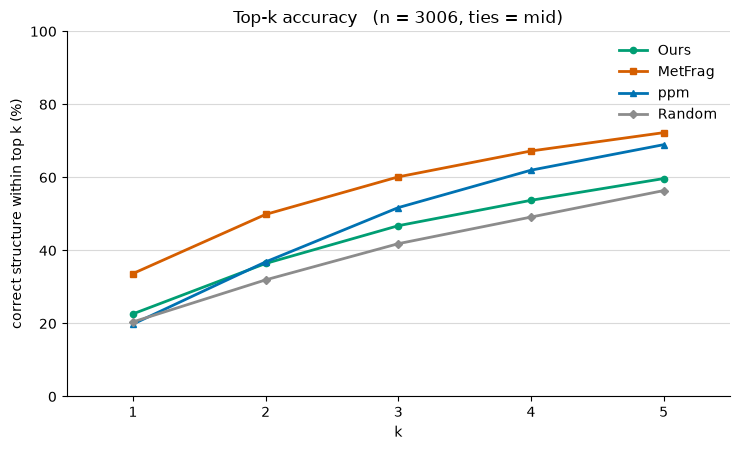

k,1,2,3,4,5
Ours,23.0,36.0,47.0,54.0,60.0
MetFrag,34.0,50.0,60.0,67.0,72.0
ppm,20.0,37.0,52.0,62.0,69.0
Random,20.0,32.0,42.0,49.0,56.0


In [88]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))

# No confidence band - the table above carries the numbers. Drawn a series at a time
# because curve.plot() would apply one marker to all four.
for key, _, _, _, label, colour in METHODS:
    ax.plot(curve.index, curve[label], color=colour, marker=MARKERS[key],
            ms=4.5, linewidth=2, label=label)
ax.set(xlabel="k", ylabel="correct structure within top k (%)", ylim=(0, 100),
       title=f"Top-k accuracy   (n = {N}, ties = {TIE_CONVENTION})")
ax.set_xticks(CURVE_TICKS)
ax.set_xlim(0.5, CURVE_MAX_K + 0.5)
ax.grid(axis="y", color="#D9D9D9", linewidth=.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "topk_curve.png"), dpi=150)
plt.show()
curve.round(0).T                      # the numbers behind the line chart

## 7. By compound class and collision energy

This section asks whether any method stands out on one class, one energy, or one combination of the two.

**Two cells: the first prints a menu, the second is the whole thing.** Edit `PICK_CLASS` and `PICK_CE` at the top of the second cell and run it — table and chart come out together.

Class is ClassyFire's `superclass`. Collision energy is binned to the four settings the library uses; V and eV are pooled, since on this instrument they name the same voltage.

In [89]:
META = r"../data/benchmark/MoNA_Agilent_QTOF_MS2_metadata.csv"

meta = pd.read_csv(META, low_memory=False,
                   usecols=["spectrum_id", "superclass", "collision_energy_value",
                            "collision_energy_unit", "n_peaks"])

def ce_bin(v):
    """Collision energy as a label, not a number - the library uses four settings and
    a short tail of one-offs, and a mean over them would be meaningless."""
    if pd.isna(v):
        return "unknown"
    v = round(float(v))
    return str(v) if v in (10, 20, 30, 40) else "other"

meta["ce_bin"] = [ce_bin(v) for v in meta.collision_energy_value]
corner_data = res.merge(meta, left_on="feature_id", right_on="spectrum_id", how="left")
print(f"metadata joined for {corner_data.superclass.notna().sum():,} of {len(corner_data):,} features\n")

print("compound classes available:")
for k, v in corner_data.superclass.value_counts().items():
    print(f"  {v:>5}  {k}")
print("\ncollision energies available:")
for k, v in corner_data.ce_bin.value_counts().items():
    print(f"  {v:>5}  CE {k}")

metadata joined for 3,006 of 3,006 features

compound classes available:
    783  Lipids and lipid-like molecules
    667  Phenylpropanoids and polyketides
    407  Organoheterocyclic compounds
    372  Organic acids and derivatives
    263  Benzenoids
    230  Organic oxygen compounds
    131  Nucleosides, nucleotides, and analogues
     64  Alkaloids and derivatives
     43  Lignans, neolignans and related compounds
     40  Organic nitrogen compounds
      3  Hydrocarbon derivatives
      2  Organosulfur compounds
      1  Organometallic compounds

collision energies available:
   1616  CE 40
    718  CE 20
    431  CE 10
    150  CE 30
     64  CE unknown
     27  CE other


### The input — edit these two lines

Both settings are **text in quotes**. A class, copied exactly as the menu spells it;
an energy — `"10"`, `"20"`, `"30"`, `"40"`; or `"all"` to not filter on that one.
Both `"all"` reproduces section 6.

Two columns guard against over-reading a small subset: **n**, what the percentages are
out of, and **vs Random**, top-1 minus the shuffle's top-1 on the same features — a
subset where everything looks good is usually one with short candidate lists.

class : Benzenoids
CE    : 10
n     : 38 features   (1% of the benchmark)   median 10 candidate structures, 22 peaks
        1 of them have a single candidate - a free top-1 for every method



,top-1,top-2,top-3,top-4,top-5,vs Random,RRP
method,,,,,,,
Ours,11%,18%,39%,45%,58%,-16,0.415
MetFrag,32%,50%,58%,66%,82%,+5,0.239
ppm,13%,26%,37%,47%,58%,-13,0.367
Random,26%,37%,47%,50%,58%,—,0.390


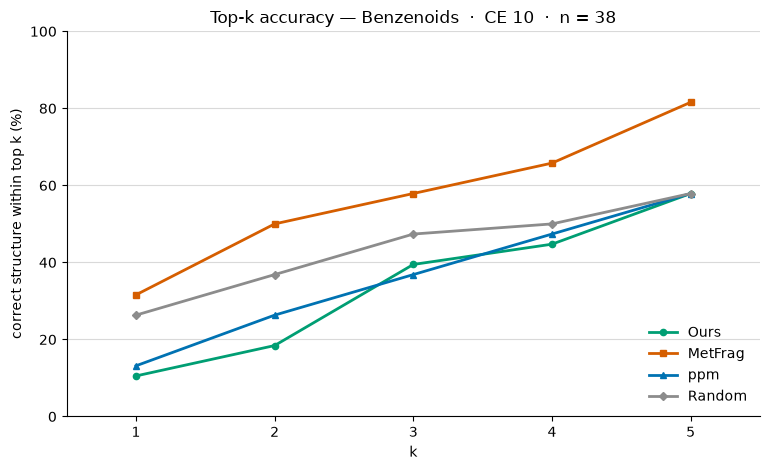

In [90]:
from IPython.display import display

PICK_CLASS = "Benzenoids"    # "all" = every class
PICK_CE    = "10"                                  # "all" = every energy


def corner(pick_class=None, pick_ce=None):
    """Table and chart for one corner - both from this one call, so that editing a
    setting and re-running cannot leave one of them showing the previous corner."""
    classes, ces = set(corner_data.superclass.dropna()), set(corner_data.ce_bin)

    # "all" switches a filter off, so both settings are always quoted text. None and a
    # few synonyms are taken too: a typo here should not read as "the corner is empty".
    def is_all(v):
        return v is None or (isinstance(v, str)
                             and v.strip().lower() in ("", "all", "none", "any"))

    if is_all(pick_class):
        if pick_class is not None:
            print(f"  (PICK_CLASS = {pick_class!r} -> every class)")
        pick_class = None
    if is_all(pick_ce):
        if pick_ce is not None:
            print(f"  (PICK_CE = {pick_ce!r} -> every energy)")
        pick_ce = None

    # Two different causes, two different fixes - so say which, not "no match".
    bad = []
    if pick_class is not None and pick_class not in classes:
        near = [c for c in sorted(classes)
                if str(pick_class).strip().lower()[:5] in c.lower()]
        bad.append(f"class {pick_class!r} is not in the menu"
                   + (f"  ->  did you mean {near[0]!r}?" if near else ""))
    if pick_ce is not None and str(pick_ce) not in ces:
        bad.append(f"CE {pick_ce!r} is not in the menu - it holds "
                   f"{sorted(ces - {'other', 'unknown'})} plus 'other' and 'unknown'")
    if bad:
        for b in bad:
            print("  !", b)
        return None

    g = corner_data
    if pick_class is not None:
        g = g[g.superclass == pick_class]
    if pick_ce is not None:
        g = g[g.ce_bin == str(pick_ce)]
    n = len(g)
    if n == 0:
        # Spelling is fine; 27 of the 78 class-by-energy cells are simply empty.
        print(f"  ! {pick_class} has no spectra at CE {pick_ce}.")
        print("    that class was measured at:")
        for k, v in corner_data[corner_data.superclass == pick_class].ce_bin.value_counts().items():
            print(f"      {v:>5}  CE {k}")
        return None
    rnd = 100*(g[f"random_rank_{TIE_CONVENTION}"] <= 1).mean()

    out = []
    for key, _, _, _, label, _ in METHODS:
        row = {"method": label}
        for k in KS:
            hit = int((g[f"{key}_rank_{TIE_CONVENTION}"] <= k).sum())
            row[f"top-{k}"] = f"{100*hit/n:.0f}%"
        t1 = 100*(g[f"{key}_rank_{TIE_CONVENTION}"] <= 1).mean()
        row["vs Random"] = "—" if label == "Random" else f"{t1 - rnd:+.0f}"
        row["RRP"] = round(g[f"{key}_rrp_{TIE_CONVENTION}"].mean(), 3)
        out.append(row)

    label_ = f"{pick_class or 'all classes'}  ·  CE {pick_ce or 'all'}  ·  n = {n}"
    print(f"class : {pick_class or 'all'}")
    print(f"CE    : {pick_ce or 'all'}")

    print(f"n     : {n} features   ({100*n/len(corner_data):.0f}% of the benchmark)"
          f"   median {int(g.ours_tc.median())} candidate structures"
          f", {int(g.n_peaks.median())} peaks")
    print(f"        {int(g.solo_candidate.sum())} of them have a single candidate"
          f" - a free top-1 for every method\n")
    display(pd.DataFrame(out).set_index("method"))

    # the same table read at every k instead of only at 1, 3, 5 and 10
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    ks = list(range(1, CURVE_MAX_K + 1))
    for key, _, _, _, label, colour in METHODS:
        ax.plot(ks, [100*(g[f"{key}_rank_{TIE_CONVENTION}"] <= k).mean() for k in ks],
                color=colour, marker=MARKERS[key], ms=4.5, linewidth=2, label=label)
    ax.set(xlabel="k", ylabel="correct structure within top k (%)", ylim=(0, 100),
           title=f"Top-k accuracy — {label_}")
    ax.set_xticks(CURVE_TICKS)
    ax.set_xlim(0.5, CURVE_MAX_K + 0.5)
    ax.grid(axis="y", color="#D9D9D9", linewidth=.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "corner_curve.png"), dpi=150)
    plt.show()


corner(PICK_CLASS, PICK_CE)

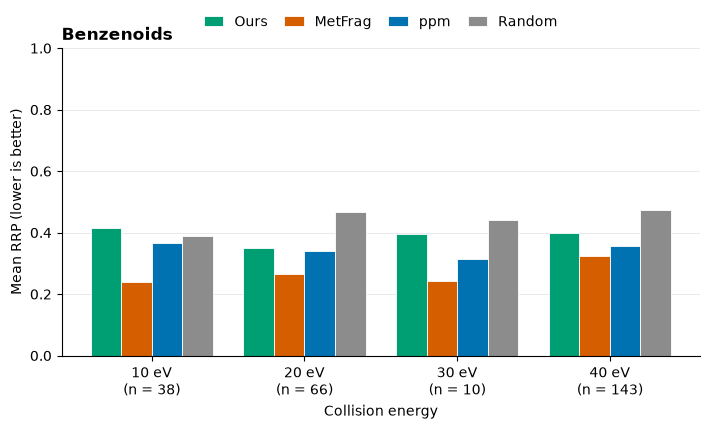

In [91]:
# Bar chart for the class in PICK_CLASS: one group per collision energy, four methods side by side.
BAR_METRIC = "rrp"     # "rrp"  = mean RRP (0 = top, lower is better; does not depend on k)
                       # "topk" = % with the correct structure within top k, k = CURVE_MAX_K
CE_ORDER = ["10", "20", "30", "40"]

pick = None if str(PICK_CLASS).strip().lower() in ("", "all", "none", "any") else PICK_CLASS
g_all = corner_data if pick is None else corner_data[corner_data.superclass == pick]

def bar_value(g, key):
    if BAR_METRIC == "topk":
        return 100*(g[f"{key}_rank_{TIE_CONVENTION}"] <= CURVE_MAX_K).mean()
    return g[f"{key}_rrp_{TIE_CONVENTION}"].mean()

ns = [int((g_all.ce_bin == ce).sum()) for ce in CE_ORDER]
x = np.arange(len(CE_ORDER))
width = 0.8 / len(METHODS)
top = 100 if BAR_METRIC == "topk" else 1

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for i, (key, _, _, _, label, colour) in enumerate(METHODS):
    vals = [bar_value(g_all[g_all.ce_bin == ce], key) if n else np.nan
            for ce, n in zip(CE_ORDER, ns)]
    ax.bar(x + (i - (len(METHODS) - 1)/2)*width, vals, width, color=colour,
           edgecolor="white", linewidth=0.6, label=label)

for xi, n in zip(x, ns):
    if n == 0:                                             # say so, rather than leave a gap
        ax.text(xi, 0.03*top, "no data", ha="center", va="bottom",
                fontsize=9, color="#8C8C8C", style="italic")

if BAR_METRIC == "topk":
    ax.set(ylabel=f"Top-{CURVE_MAX_K} accuracy (%)", ylim=(0, 100))
else:
    ax.set(ylabel="Mean RRP (lower is better)", ylim=(0, 1))
ax.set_xticks(x)
ax.set_xticklabels([f"{ce} eV\n(n = {n})" for ce, n in zip(CE_ORDER, ns)])
ax.set_xlabel("Collision energy")
ax.set_title(f"{pick or 'All classes'}", loc="left", fontweight="bold")
ax.grid(axis="y", color="#E5E5E5", linewidth=.6)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, ncol=len(METHODS), loc="lower center",
          bbox_to_anchor=(0.5, 1.02), handlelength=1.4, columnspacing=1.2)

fig.tight_layout()
for ext in ("png", "pdf"):                                 # pdf = vector, for the manuscript
    fig.savefig(os.path.join(FIG_DIR, f"class_by_ce_bars.{ext}"), dpi=300)
plt.show()

## 8. What this comes to

MetFrag ranks better at every k, and the two fail differently: **ours cannot separate
the candidates at all on 579 features**. The score narrows the list and then has
nothing left to choose with. **The next step is a tie-breaker, not a better score.**

ppm makes the point in a purer form — it ranks formulas, not molecules, yet matches
MetFrag on RRP and beats it at top-10. Almost all the *narrowing* here comes from the
precursor mass alone; fragmentation earns its keep only in the last step.

### Three cells worth a look

Sweeping every class × energy cell with 30 or more features leaves 24, and **we beat
MetFrag in none.** Three of them stand out:

- **Lipids · CE 40** (n = 400) — a dead tie, 25.5% against 25.8%. All three lipid
  cells are among the four closest in the sweep, so it is not one lucky subset.
- **Organoheterocyclics · CE 20** (n = 89) — our top-1 equals the shuffle's, 14.6%
  both, and barely moves with energy while MetFrag's falls from 47% to 28%. Three of
  the four organoheterocyclic cells behave the same way.
- **Phenylpropanoids · CE 40** (n = 459) — the largest cell in the sweep and the
  clearest deficit, 13.5% against 28.1%.

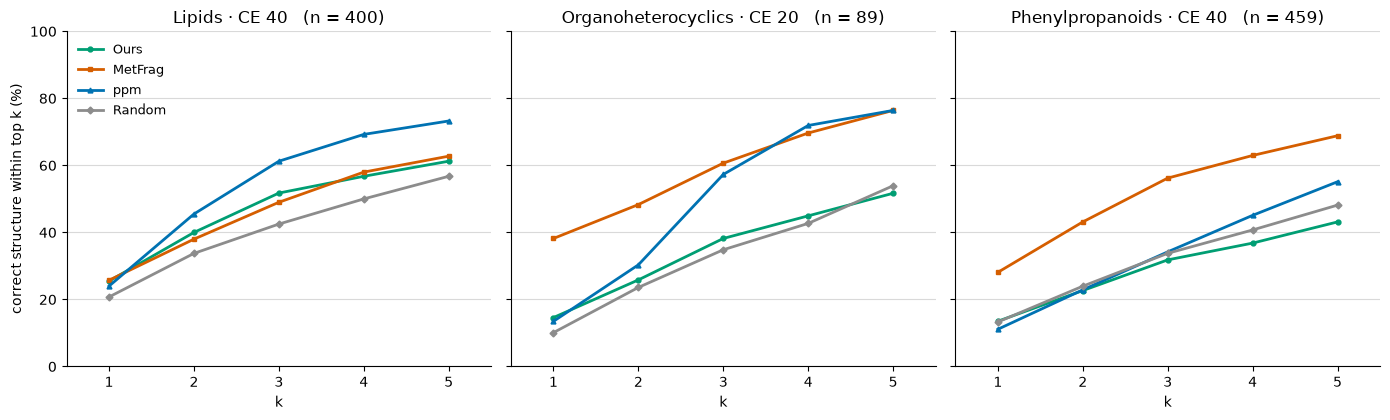

In [92]:
PANELS = [("Lipids · CE 40", "Lipids and lipid-like molecules", "40"),
          ("Organoheterocyclics · CE 20", "Organoheterocyclic compounds", "20"),
          ("Phenylpropanoids · CE 40", "Phenylpropanoids and polyketides", "40")]

fig, ax = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
ks = list(range(1, CURVE_MAX_K + 1))

for a, (name, cls, ce) in zip(ax, PANELS):
    g = corner_data[(corner_data.superclass == cls) & (corner_data.ce_bin == ce)]
    for key, _, _, _, label, colour in METHODS:
        a.plot(ks, [100*(g[f"{key}_rank_{TIE_CONVENTION}"] <= k).mean() for k in ks],
               color=colour, marker=MARKERS[key], ms=3.5, linewidth=2, label=label)
    a.set(xlabel="k", ylim=(0, 100), title=f"{name}   (n = {len(g):,})")
    a.set_xticks(CURVE_TICKS)
    a.set_xlim(0.5, CURVE_MAX_K + 0.5)
    a.grid(axis="y", color="#D9D9D9", linewidth=.8)
    a.set_axisbelow(True)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)

ax[0].set_ylabel("correct structure within top k (%)")
ax[0].legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "strata.png"), dpi=150)
plt.show()

## 9. Save

In [93]:
res.to_csv(os.path.join(OUT_DIR, "per_feature.csv"), index=False, encoding="utf-8-sig")
main.to_csv(os.path.join(OUT_DIR, "headline.csv"), encoding="utf-8-sig")
print("written to", OUT_DIR)
print(" per_feature.csv   one row per feature: BC/EC/TC and every rank and RRP")
print(" headline.csv      the main table")
print(" figures/topk_curve.png    figure 1 - the whole benchmark")
print(" figures/corner_curve.png  figure 2 - the subset set in section 7")

written to .
 per_feature.csv   one row per feature: BC/EC/TC and every rank and RRP
 headline.csv      the main table
 figures/topk_curve.png    figure 1 - the whole benchmark
 figures/corner_curve.png  figure 2 - the subset set in section 7
